# Tourism Data Science Project: Hotel Booking Demand

## Research Focus
This project uses an open tourism-related dataset of hotel bookings to answer two core questions:

1. Which booking and traveler factors are most associated with hotel booking cancellations?
2. How well can machine learning models predict whether a tourism booking will be canceled?

## Dataset
- Name: Hotel Booking Demand Dataset
- Original source article: Antonio, N., de Almeida, A., & Nunes, L. (2019). *Hotel booking demand datasets*. *Data in Brief, 22*, 41-49. https://doi.org/10.1016/j.dib.2018.11.126
- Downloaded CSV mirror used in this workspace: `https://raw.githubusercontent.com/salves94/hotel-exploratory-data-analysis/master/hotel_bookings.csv`
- File format: CSV

## Leakage Note
This notebook avoids obvious leakage by excluding `reservation_status` and `reservation_status_date`, which are post-booking outcome fields.


In [1]:
import os
from pathlib import Path

os.environ["MPLCONFIGDIR"] = str(Path('.').resolve() / '.mplcache')
os.environ["XDG_CACHE_HOME"] = str(Path('.').resolve() / '.cache')

Path('figures').mkdir(exist_ok=True)
Path('results').mkdir(exist_ok=True)
Path('.mplcache').mkdir(exist_ok=True)
Path('.cache').mkdir(exist_ok=True)


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42


In [3]:
df = pd.read_csv('data/hotel_bookings.csv')
print('Shape:', df.shape)
print('Columns:', len(df.columns))
df.head()


Shape: (119390, 32)
Columns: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing.to_frame('missing_values')


,missing_values
company,112593
agent,16340
country,488
children,4


## Data Cleaning And Feature Engineering
The dataset is rich enough for meaningful tourism analysis. The notebook keeps pre-booking and booking-time variables, fills manageable missing values, and engineers travel-relevant features such as total nights and family size.


In [5]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

clean = df.copy()
clean['children'] = clean['children'].fillna(0)
clean['country'] = clean['country'].fillna('Unknown')
clean['total_nights'] = clean['stays_in_weekend_nights'] + clean['stays_in_week_nights']
clean['family_size'] = clean['adults'] + clean['children'] + clean['babies']
clean['is_family'] = ((clean['children'] + clean['babies']) > 0).astype(int)
clean['arrival_month_num'] = pd.Categorical(clean['arrival_date_month'], categories=month_order, ordered=True).codes + 1

top_countries = clean['country'].value_counts().head(15).index
clean['country_grouped'] = clean['country'].where(clean['country'].isin(top_countries), 'Other')

clean[['is_canceled', 'hotel', 'lead_time', 'market_segment', 'deposit_type', 'adr', 'total_nights', 'family_size']].head()


,is_canceled,hotel,lead_time,market_segment,deposit_type,adr,total_nights,family_size
0,0,Resort Hotel,342,Direct,No Deposit,0.0,0,2.0
1,0,Resort Hotel,737,Direct,No Deposit,0.0,0,2.0
2,0,Resort Hotel,7,Direct,No Deposit,75.0,1,1.0
3,0,Resort Hotel,13,Corporate,No Deposit,75.0,1,1.0
4,0,Resort Hotel,14,Online TA,No Deposit,98.0,2,2.0


## Descriptive Analysis

In [6]:
overall_cancel_rate = clean['is_canceled'].mean()
hotel_cancel = clean.groupby('hotel')['is_canceled'].mean().sort_values(ascending=False)
segment_cancel = clean.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False)

print(f'Overall cancellation rate: {overall_cancel_rate:.2%}')
print('\nCancellation rate by hotel:')
print((hotel_cancel * 100).round(2).to_string())
print('\nTop market segments by cancellation rate:')
print((segment_cancel.head(8) * 100).round(2).to_string())


Overall cancellation rate: 37.04%

Cancellation rate by hotel:
hotel
City Hotel      41.73
Resort Hotel    27.76

Top market segments by cancellation rate:
market_segment
Undefined        100.00
Groups            61.06
Online TA         36.72
Offline TA/TO     34.32
Aviation          21.94
Corporate         18.73
Direct            15.34
Complementary     13.06


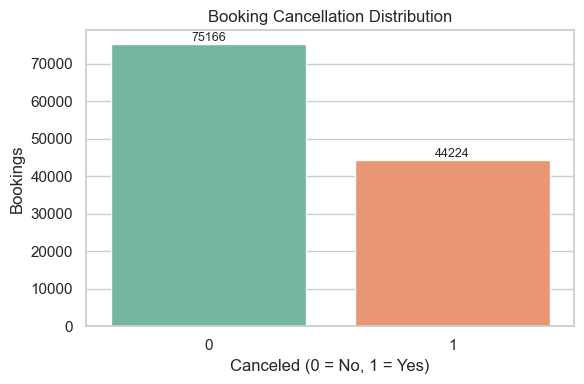

In [7]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=clean, x='is_canceled', hue='is_canceled', palette='Set2', legend=False)
ax.set_title('Booking Cancellation Distribution')
ax.set_xlabel('Canceled (0 = No, 1 = Yes)')
ax.set_ylabel('Bookings')
for patch in ax.patches:
    ax.annotate(f'{int(patch.get_height())}', (patch.get_x() + patch.get_width()/2, patch.get_height()), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('figures/cancellation_distribution.png', dpi=200)
plt.show()


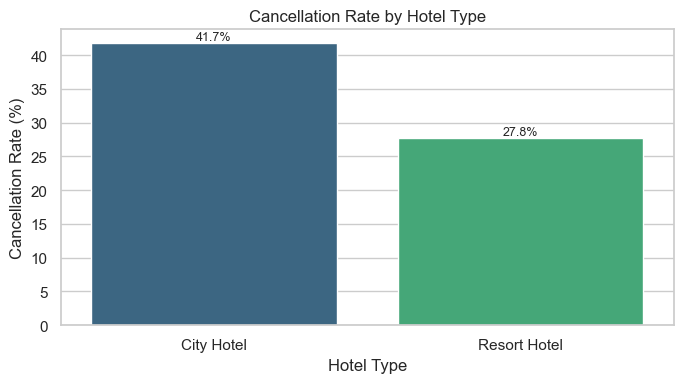

In [8]:
hotel_plot = clean.groupby('hotel', as_index=False)['is_canceled'].mean().sort_values('is_canceled', ascending=False)
hotel_plot['is_canceled'] *= 100
plt.figure(figsize=(7, 4))
ax = sns.barplot(data=hotel_plot, x='hotel', y='is_canceled', hue='hotel', palette='viridis', legend=False)
ax.set_title('Cancellation Rate by Hotel Type')
ax.set_xlabel('Hotel Type')
ax.set_ylabel('Cancellation Rate (%)')
for patch in ax.patches:
    ax.annotate(f'{patch.get_height():.1f}%', (patch.get_x() + patch.get_width()/2, patch.get_height()), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('figures/cancellation_rate_by_hotel.png', dpi=200)
plt.show()


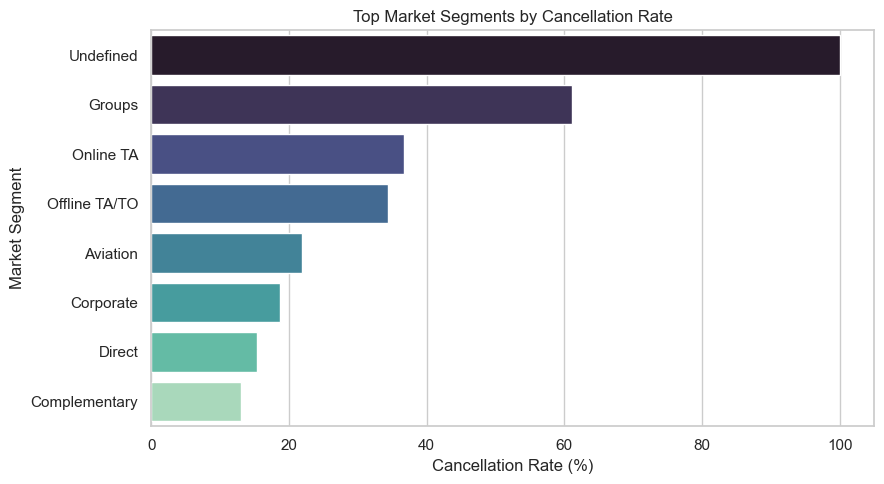

In [9]:
segment_plot = clean.groupby('market_segment', as_index=False)['is_canceled'].mean().sort_values('is_canceled', ascending=False).head(8)
segment_plot['is_canceled'] *= 100
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=segment_plot, x='is_canceled', y='market_segment', hue='market_segment', palette='mako', legend=False)
ax.set_title('Top Market Segments by Cancellation Rate')
ax.set_xlabel('Cancellation Rate (%)')
ax.set_ylabel('Market Segment')
plt.tight_layout()
plt.savefig('figures/cancellation_rate_by_market_segment.png', dpi=200)
plt.show()


## Correlation Matrix

In [10]:
numeric_corr_cols = [
    'is_canceled', 'lead_time', 'arrival_month_num', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'total_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations',
    'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr',
    'required_car_parking_spaces', 'total_of_special_requests', 'family_size'
]

corr = clean[numeric_corr_cols].corr(numeric_only=True)
corr.to_csv('results/correlation_matrix.csv')

top_corr = corr['is_canceled'].sort_values(ascending=False).reset_index()
top_corr.columns = ['feature', 'correlation_with_is_canceled']
top_corr.to_csv('results/top_correlations_with_cancellation.csv', index=False)
top_corr


,feature,correlation_with_is_canceled
0,is_canceled,1.000000
1,lead_time,0.293123
2,previous_cancellations,0.110133
3,adults,0.060017
4,days_in_waiting_list,0.054186
5,adr,0.047557
6,family_size,0.046522
7,stays_in_week_nights,0.024765
8,total_nights,0.017779
9,arrival_month_num,0.011022


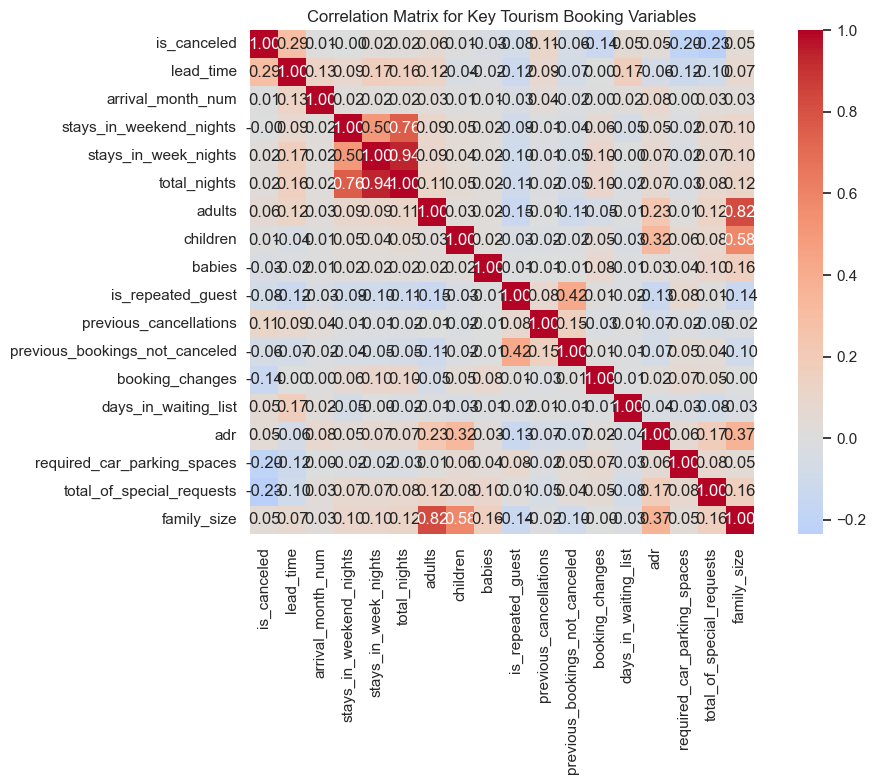

In [11]:
plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', square=True)
plt.title('Correlation Matrix for Key Tourism Booking Variables')
plt.tight_layout()
plt.savefig('figures/correlation_matrix.png', dpi=200)
plt.show()


## Machine Learning: Predicting Booking Cancellation
The target is `is_canceled`. To keep the model honest, post-outcome leakage variables are excluded.


In [12]:
ml = clean.copy()

leakage_columns = ['reservation_status', 'reservation_status_date']
drop_columns = leakage_columns + ['is_canceled', 'country', 'agent', 'company']

X = ml.drop(columns=drop_columns)
y = ml['is_canceled']

categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=4000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_leaf=40, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, min_samples_leaf=10, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1)
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

results = []
fitted_models = {}
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    fitted_models[name] = pipe
    results.append({
        'model': name,
        'accuracy': round(accuracy_score(y_test, pred), 4),
        'precision': round(precision_score(y_test, pred), 4),
        'recall': round(recall_score(y_test, pred), 4),
        'f1': round(f1_score(y_test, pred), 4),
        'roc_auc': round(roc_auc_score(y_test, proba), 4),
    })

metrics = pd.DataFrame(results).sort_values(['roc_auc', 'f1'], ascending=False).reset_index(drop=True)
metrics.to_csv('results/model_metrics.csv', index=False)
metrics


/var/folders/6f/_1_05m3x5_jdc82841wxg75r0000gn/T/ipykernel_64171/2888900751.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.8713,0.8224,0.8324,0.8274,0.9451
1,Decision Tree,0.7955,0.6737,0.8686,0.7589,0.9061
2,Logistic Regression,0.8077,0.7232,0.7792,0.7501,0.8949


In [13]:
best_model_name = metrics.iloc[0]['model']
best_model = fitted_models[best_model_name]
best_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_pred)
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])
cm_df.to_csv('results/confusion_matrix.csv')
cm_df


,Predicted 0,Predicted 1
Actual 0,13443,1590
Actual 1,1482,7363


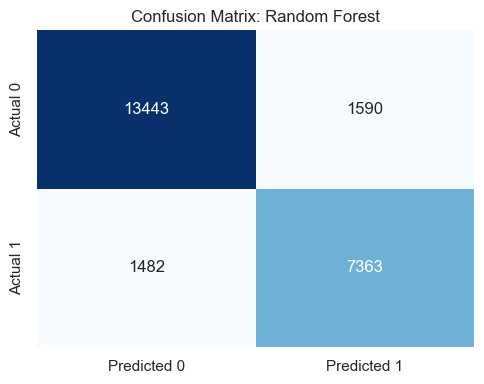

In [14]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix: {best_model_name}')
plt.tight_layout()
plt.savefig('figures/confusion_matrix_best_model.png', dpi=200)
plt.show()


In [15]:
rf = fitted_models['Random Forest']
feature_names = rf.named_steps['preprocessor'].get_feature_names_out()
importances = pd.Series(rf.named_steps['model'].feature_importances_, index=feature_names).sort_values(ascending=False)
importance_df = importances.head(20).reset_index()
importance_df.columns = ['feature', 'importance']
importance_df.to_csv('results/random_forest_feature_importance.csv', index=False)
importance_df.head(10)


,feature,importance
0,cat__deposit_type_Non Refund,0.116232
1,cat__country_grouped_PRT,0.108113
2,num__lead_time,0.099580
3,cat__deposit_type_No Deposit,0.070372
4,num__total_of_special_requests,0.066663
5,cat__market_segment_Online TA,0.040630
6,num__required_car_parking_spaces,0.039100
7,num__adr,0.036141
8,num__previous_cancellations,0.032327
9,cat__customer_type_Transient,0.022532


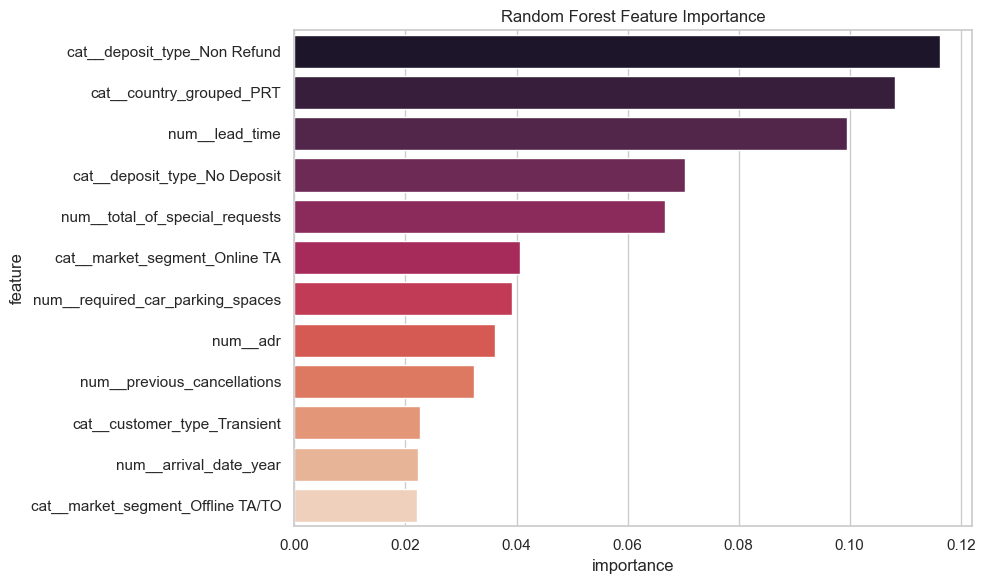

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(12), x='importance', y='feature', hue='feature', palette='rocket', legend=False)
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('figures/random_forest_feature_importance.png', dpi=200)
plt.show()


In [17]:
summary_lines = [
    'Tourism Data Science Project Summary',
    '',
    'Dataset:',
    '- Name: Hotel Booking Demand Dataset',
    '- File: data/hotel_bookings.csv',
    '- Format: CSV',
    '- Original article: Antonio, N., de Almeida, A., & Nunes, L. (2019). Hotel booking demand datasets. Data in Brief, 22, 41-49. DOI: 10.1016/j.dib.2018.11.126',
    '- Download mirror used in this workspace: https://raw.githubusercontent.com/salves94/hotel-exploratory-data-analysis/master/hotel_bookings.csv',
    '',
    'Research questions:',
    '1. Which hotel booking factors are most associated with cancellation?',
    '2. Can machine learning predict booking cancellation accurately from booking-time tourism variables?',
    '',
    f'Overall cancellation rate: {overall_cancel_rate:.2%}',
    f'Best model: {best_model_name}',
    f"Best model accuracy: {metrics.iloc[0]['accuracy']:.4f}",
    f"Best model F1: {metrics.iloc[0]['f1']:.4f}",
    f"Best model ROC AUC: {metrics.iloc[0]['roc_auc']:.4f}",
    '',
    'Top numeric correlations with cancellation:',
]

for _, row in top_corr.head(8).iterrows():
    summary_lines.append(f"- {row['feature']}: {row['correlation_with_is_canceled']:.4f}")

summary_lines += [
    '',
    'Leakage prevention:',
    '- reservation_status and reservation_status_date were excluded from machine learning because they directly reflect the booking outcome.',
    '',
    'Main output files:',
    '- figures/cancellation_distribution.png',
    '- figures/cancellation_rate_by_hotel.png',
    '- figures/cancellation_rate_by_market_segment.png',
    '- figures/correlation_matrix.png',
    '- figures/confusion_matrix_best_model.png',
    '- figures/random_forest_feature_importance.png',
    '- results/model_metrics.csv',
    '- results/top_correlations_with_cancellation.csv',
    '- results/random_forest_feature_importance.csv',
    '- results/confusion_matrix.csv',
]

Path('project_info.txt').write_text('\n'.join(summary_lines))
print(Path('project_info.txt').read_text())


Tourism Data Science Project Summary

Dataset:
- Name: Hotel Booking Demand Dataset
- File: data/hotel_bookings.csv
- Format: CSV
- Original article: Antonio, N., de Almeida, A., & Nunes, L. (2019). Hotel booking demand datasets. Data in Brief, 22, 41-49. DOI: 10.1016/j.dib.2018.11.126
- Download mirror used in this workspace: https://raw.githubusercontent.com/salves94/hotel-exploratory-data-analysis/master/hotel_bookings.csv

Research questions:
1. Which hotel booking factors are most associated with cancellation?
2. Can machine learning predict booking cancellation accurately from booking-time tourism variables?

Overall cancellation rate: 37.04%
Best model: Random Forest
Best model accuracy: 0.8713
Best model F1: 0.8274
Best model ROC AUC: 0.9451

Top numeric correlations with cancellation:
- is_canceled: 1.0000
- lead_time: 0.2931
- previous_cancellations: 0.1101
- adults: 0.0600
- days_in_waiting_list: 0.0542
- adr: 0.0476
- family_size: 0.0465
- stays_in_week_nights: 0.0248

Leak

## Final Interpretation
This dataset is stronger for a tourism data science project because the relationships are not just a rating predicting satisfaction. Instead, it supports meaningful tourism behavior questions about booking patterns, cancellation risk, lead time, pricing, and customer behavior.
